
# 1. Title

## Intrusion Detection Analysis using Exploratory Data Analysis and Machine Learning

**Program:** Maestria en Ciencia de Datos  
**Project:** `intrusion-detection-eda`  
**Main notebook artifact:** `notebooks/01_intrusion_detection_eda.ipynb`



# 2. Introduction

La deteccion de intrusiones es un problema central en ciberseguridad porque permite identificar actividad maliciosa en etapas tempranas. En escenarios reales, la simple inspeccion manual del trafico no escala, por lo que el analisis de datos y el modelado estadistico son herramientas clave.

En este trabajo se desarrolla un flujo de analisis academico y reproducible para:

- caracterizar el comportamiento del trafico de red;
- identificar patrones que diferencian trafico normal y malicioso;
- construir una linea base de clasificacion supervisada.



# 3. Dataset Description

Se utilizan dos archivos tabulares:

- `train_data.csv` (o `Train_data.csv` segun el entorno local).
- `test_data.csv`.

Cada fila representa una conexion de red y contiene variables de trafico, conteo y tasas de error.

La variable objetivo es **`xAttack`**, con clases observadas en entrenamiento:

- `normal`
- `dos`
- `probe`
- `r2l`
- `u2r`

Las variables incluyen:

- numericas continuas (por ejemplo, tasas como `serror_rate`);
- enteras de conteo (`count`, `srv_count`, `dst_host_count`);
- categoricas (`protocol_type`) y codificadas numericamente (`service`, `flag`).



# 4. Data Loading

Se respetan rutas relativas requeridas por el enunciado:

- `../data/train_data.csv`
- `../data/test_data.csv`

Adicionalmente se agrega fallback para ejecucion desde la raiz del repositorio o variacion de mayusculas en el nombre del archivo de entrenamiento.


In [1]:

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [2]:

train_candidates = [
    Path("../data/train_data.csv"),
    Path("../data/Train_data.csv"),
    Path("data/train_data.csv"),
    Path("data/Train_data.csv"),
]

test_candidates = [
    Path("../data/test_data.csv"),
    Path("data/test_data.csv"),
]

train_path = next((p for p in train_candidates if p.exists()), None)
test_path = next((p for p in test_candidates if p.exists()), None)

assert train_path is not None, "Train dataset not found in expected relative paths."
assert test_path is not None, "Test dataset not found in expected relative paths."

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print(f"Train file: {train_path}")
print(f"Test file:  {test_path}")
print("Data loaded.")


Train file: data\train_data.csv
Test file:  data\test_data.csv
Data loaded.



# 5. Initial Data Inspection

En esta fase se inspecciona estructura, columnas y tipos de datos para validar coherencia entre train y test.


In [3]:

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

print()
print("Train columns:")
print(df_train.columns.tolist())

print()
print("Test columns:")
print(df_test.columns.tolist())


Train shape: (125973, 42)
Test shape: (10000, 43)

Train columns:
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'xAttack']

Test columns:
['Unnamed: 0', 'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromi

In [4]:

display(df_train.head())
display(df_test.head())


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,xAttack
0,0,icmp,20,2,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.00,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,45,2,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,icmp,50,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,dos
3,0,icmp,25,2,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,icmp,25,2,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


,Unnamed: 0,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,xAttack
0,202,0,icmp,25,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,110,110,1.0,1.0,0.0,0.0,1.0,0.0,0.00,255,255,1.00,0.00,0.00,0.00,0.65,0.65,0.32,0.32,dos
1,768,0,icmp,25,2,312,1856,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,9,0.0,0.0,0.0,0.0,1.0,0.0,0.33,1,254,1.00,0.00,1.00,0.06,0.00,0.00,0.00,0.00,normal
2,3753,0,icmp,25,2,245,2058,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.0,0.0,0.0,0.0,1.0,0.0,0.00,114,255,1.00,0.00,0.01,0.05,0.01,0.00,0.00,0.00,normal
3,20087,0,icmp,25,2,298,1267,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,4,18,0.0,0.0,0.0,0.0,1.0,0.0,0.11,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal
4,16159,0,icmp,20,2,740,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.0,0.0,0.0,1.0,0.0,0.00,104,19,0.18,0.03,0.18,0.00,0.00,0.00,0.00,0.00,normal


In [5]:

print("Train info:")
df_train.info()

print()
print("Test info:")
df_test.info()


Train info:
<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  str    
 2   service                      125973 non-null  int64  
 3   flag                         125973 non-null  int64  
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13


**Observacion inicial**

La estructura general es consistente. `xAttack` aparece como variable objetivo y `df_test` contiene una columna adicional `Unnamed: 0`, consistente con un indice exportado.



# 6. Data Quality Analysis

Se analiza calidad de datos con foco en:

- valores nulos;
- duplicados;
- consistencia de columnas;
- distribucion de clases objetivo.


In [6]:

quality_summary = pd.DataFrame(
    {
        "dataset": ["train", "test"],
        "rows": [df_train.shape[0], df_test.shape[0]],
        "columns": [df_train.shape[1], df_test.shape[1]],
        "null_values": [int(df_train.isnull().sum().sum()), int(df_test.isnull().sum().sum())],
        "duplicate_rows": [int(df_train.duplicated().sum()), int(df_test.duplicated().sum())],
    }
)

display(quality_summary)


,dataset,rows,columns,null_values,duplicate_rows
0,train,125973,42,0,32
1,test,10000,43,0,0


In [7]:

print("Nulls in train by column (only > 0):")
train_nulls = df_train.isnull().sum()
display(train_nulls[train_nulls > 0])

print("Nulls in test by column (only > 0):")
test_nulls = df_test.isnull().sum()
display(test_nulls[test_nulls > 0])

train_cols = set(df_train.columns)
test_cols = set(df_test.columns)

print()
print("Columns extra in test:", sorted(test_cols - train_cols))
print("Columns missing in test:", sorted(train_cols - test_cols))


Nulls in train by column (only > 0):


Series([], dtype: int64)

Nulls in test by column (only > 0):


Series([], dtype: int64)


Columns extra in test: ['Unnamed: 0']
Columns missing in test: []


In [8]:

if "xAttack" in df_train.columns:
    class_dist_raw = (
        df_train["xAttack"]
        .value_counts(dropna=False)
        .rename_axis("xAttack")
        .to_frame("count")
    )
    class_dist_raw["percentage"] = (100 * class_dist_raw["count"] / len(df_train)).round(2)
    display(class_dist_raw)


,count,percentage
xAttack,,
normal,67343,53.46
dos,45927,36.46
probe,11656,9.25
r2l,995,0.79
u2r,52,0.04



**Interpretacion de calidad**

No se observan nulos. Existen duplicados en entrenamiento y una columna tecnica adicional en test (`Unnamed: 0`) que debe removerse. La variable objetivo presenta desbalance de clases.



# 7. Data Cleaning

Transformaciones aplicadas:

1. Eliminar `Unnamed: 0` si existe.
2. Eliminar duplicados.
3. Tipar variables categoricas (`protocol_type`, `xAttack`) como `category`.
4. Conservar outliers por su valor analitico en deteccion de intrusiones.


In [9]:

df_train_clean = df_train.copy()
df_test_clean = df_test.copy()

for frame in [df_train_clean, df_test_clean]:
    if "Unnamed: 0" in frame.columns:
        frame.drop(columns=["Unnamed: 0"], inplace=True)

train_dup_before = int(df_train_clean.duplicated().sum())
test_dup_before = int(df_test_clean.duplicated().sum())

df_train_clean = df_train_clean.drop_duplicates().reset_index(drop=True)
df_test_clean = df_test_clean.drop_duplicates().reset_index(drop=True)

for col in ["protocol_type", "xAttack"]:
    if col in df_train_clean.columns:
        df_train_clean[col] = df_train_clean[col].astype("category")
    if col in df_test_clean.columns:
        df_test_clean[col] = df_test_clean[col].astype("category")

clean_report = pd.DataFrame(
    {
        "dataset": ["train", "test"],
        "rows_before": [df_train.shape[0], df_test.shape[0]],
        "rows_after": [df_train_clean.shape[0], df_test_clean.shape[0]],
        "duplicates_removed": [train_dup_before, test_dup_before],
        "null_values_after": [
            int(df_train_clean.isnull().sum().sum()),
            int(df_test_clean.isnull().sum().sum()),
        ],
    }
)

display(clean_report)


,dataset,rows_before,rows_after,duplicates_removed,null_values_after
0,train,125973,125941,32,0
1,test,10000,9999,1,0


In [10]:

print("Train dtypes sample:")
display(df_train_clean.dtypes.head(12))

print()
print("Test dtypes sample:")
display(df_test_clean.dtypes.head(12))

print()
print("Column consistency after cleaning:")
print("In train not in test:", sorted(set(df_train_clean.columns) - set(df_test_clean.columns)))
print("In test not in train:", sorted(set(df_test_clean.columns) - set(df_train_clean.columns)))


Train dtypes sample:


duration                int64
protocol_type        category
service                 int64
flag                    int64
src_bytes               int64
dst_bytes               int64
land                    int64
wrong_fragment          int64
urgent                  int64
hot                     int64
num_failed_logins       int64
logged_in               int64
dtype: object


Test dtypes sample:


duration                int64
protocol_type        category
service                 int64
flag                    int64
src_bytes               int64
dst_bytes               int64
land                    int64
wrong_fragment          int64
urgent                  int64
hot                     int64
num_failed_logins       int64
logged_in               int64
dtype: object


Column consistency after cleaning:
In train not in test: []
In test not in train: []



**Interpretacion de limpieza**

La limpieza mejora consistencia entre particiones y elimina sesgo por repeticion de registros. No se aplico imputacion al no existir nulos.



# 8. Exploratory Data Analysis (EDA)

El EDA busca evidencias para diferenciar trafico benigno y malicioso en terminos de distribuciones, patrones por clase y comportamiento por protocolo.


In [11]:

class_dist_clean = (
    df_train_clean["xAttack"]
    .value_counts()
    .rename_axis("xAttack")
    .to_frame("count")
)
class_dist_clean["percentage"] = (100 * class_dist_clean["count"] / len(df_train_clean)).round(2)
display(class_dist_clean)


,count,percentage
xAttack,,
normal,67343,53.47
dos,45909,36.45
probe,11642,9.24
r2l,995,0.79
u2r,52,0.04


In [12]:

selected_num = [
    "duration", "src_bytes", "dst_bytes", "count", "srv_count",
    "serror_rate", "rerror_rate", "same_srv_rate", "diff_srv_rate",
]
selected_num = [c for c in selected_num if c in df_train_clean.columns]

display(df_train_clean[selected_num].describe().T)

class_means = df_train_clean.groupby("xAttack", observed=False)[selected_num].mean().round(4)
display(class_means)


,count,mean,std,min,25%,50%,75%,max
duration,125941.0,287.217610,2.604842e+03,0.0,0.00,0.0,0.00,4.290800e+04
src_bytes,125941.0,45578.320356,5.871077e+06,0.0,0.00,44.0,276.00,1.379964e+09
dst_bytes,125941.0,19784.140042,4.021780e+06,0.0,0.00,0.0,516.00,1.309937e+09
count,125941.0,84.095140,1.145040e+02,0.0,2.00,14.0,143.00,5.110000e+02
srv_count,125941.0,27.742840,7.264426e+01,0.0,2.00,8.0,18.00,5.110000e+02
serror_rate,125941.0,0.284398,4.464126e-01,0.0,0.00,0.0,1.00,1.000000e+00
rerror_rate,125941.0,0.119965,3.204423e-01,0.0,0.00,0.0,0.00,1.000000e+00
same_srv_rate,125941.0,0.660982,4.396036e-01,0.0,0.09,1.0,1.00,1.000000e+00
diff_srv_rate,125941.0,0.063052,1.803168e-01,0.0,0.00,0.0,0.06,1.000000e+00


,duration,src_bytes,dst_bytes,count,srv_count,serror_rate,rerror_rate,same_srv_rate,diff_srv_rate
xAttack,,,,,,,,,
dos,0.0062,1176.7824,169.2679,178.0675,32.6648,0.7484,0.1522,0.1919,0.0654
normal,168.5874,13133.2793,4329.6852,22.5179,27.6857,0.0134,0.0442,0.9694,0.0288
probe,2077.3533,386143.6286,181292.6621,77.1435,10.9436,0.0464,0.4376,0.6969,0.2568
r2l,633.4171,307727.3005,81822.0261,1.2975,2.4573,0.0119,0.0518,0.9967,0.0067
u2r,80.9423,906.2308,5141.9615,5.8077,1.2692,0.0381,0.0098,0.9315,0.0637


In [13]:

protocol_class_share = pd.crosstab(
    df_train_clean["protocol_type"],
    df_train_clean["xAttack"],
    normalize="columns",
).round(3)
display(protocol_class_share)


xAttack,dos,normal,probe,r2l,u2r
protocol_type,,,,,
icmp,0.919,0.796,0.503,1.0,0.942
tcp,0.062,0.019,0.354,0.0,0.000
udp,0.019,0.185,0.143,0.0,0.058


In [14]:

outlier_features = [c for c in ["src_bytes", "dst_bytes", "count", "srv_count", "duration"] if c in df_train_clean.columns]

outlier_rows = []
for col in outlier_features:
    q1 = df_train_clean[col].quantile(0.25)
    q3 = df_train_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    overall_ratio = ((df_train_clean[col] < lower) | (df_train_clean[col] > upper)).mean()

    outlier_by_class = (
        df_train_clean.assign(is_outlier=((df_train_clean[col] < lower) | (df_train_clean[col] > upper)))
        .groupby("xAttack", observed=False)["is_outlier"]
        .mean()
        .round(4)
        .to_dict()
    )

    outlier_rows.append(
        {
            "feature": col,
            "outlier_ratio_total": round(float(overall_ratio), 4),
            **{f"outlier_ratio_{k}": v for k, v in outlier_by_class.items()},
        }
    )

outlier_report = pd.DataFrame(outlier_rows)
display(outlier_report)


,feature,outlier_ratio_total,outlier_ratio_dos,outlier_ratio_normal,outlier_ratio_probe,outlier_ratio_r2l,outlier_ratio_u2r
0,src_bytes,0.1099,0.0687,0.1519,0.0015,0.4221,0.3846
1,dst_bytes,0.1872,0.0208,0.3304,0.0006,0.3286,0.7885
2,count,0.0251,0.0372,0.0022,0.1115,0.0000,0.0000
3,srv_count,0.0957,0.0662,0.1214,0.0713,0.0080,0.0000
4,duration,0.0795,0.0009,0.1182,0.1371,0.3889,0.7115



**Interpretacion EDA**

Las clases presentan perfiles estadisticos distintos y las variables de bytes, conteos y tasas muestran patrones utiles para discriminacion de ataques.



# 9. Data Visualization

Se construyen visualizaciones orientadas a interpretacion cibersegura: distribucion de clases, forma de variables numericas, dispersion por clase y patrones de protocolo/servicio.



## 9.1 Countplot de clases


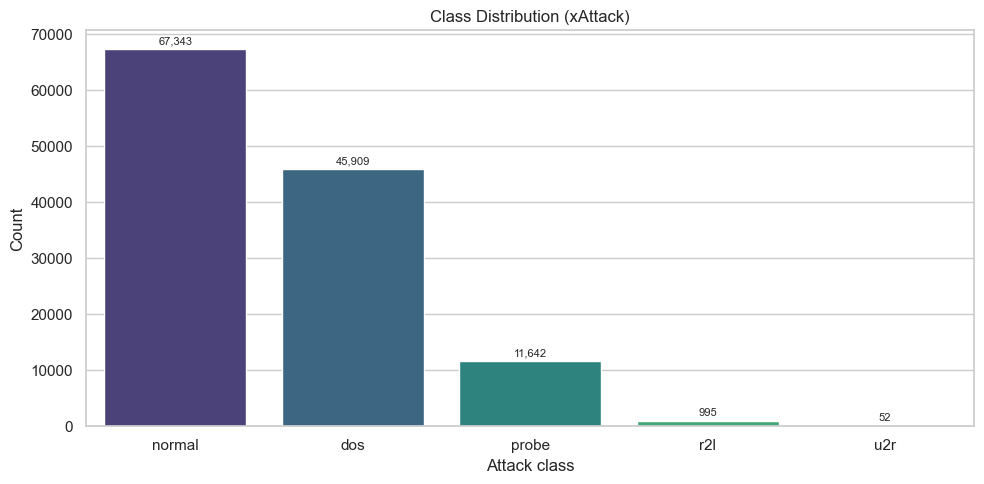

In [15]:

plt.figure(figsize=(10, 5))
order = df_train_clean["xAttack"].value_counts().index
ax = sns.countplot(data=df_train_clean, x="xAttack", order=order, palette="viridis")
ax.set_title("Class Distribution (xAttack)")
ax.set_xlabel("Attack class")
ax.set_ylabel("Count")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=8,
        xytext=(0, 2),
        textcoords="offset points",
    )

plt.tight_layout()
plt.show()



**Interpretacion:** existe desbalance fuerte, con clases minoritarias (`u2r`, `r2l`) que requieren metricas macro y analisis detallado de error.



## 9.2 Histogramas de variables numericas


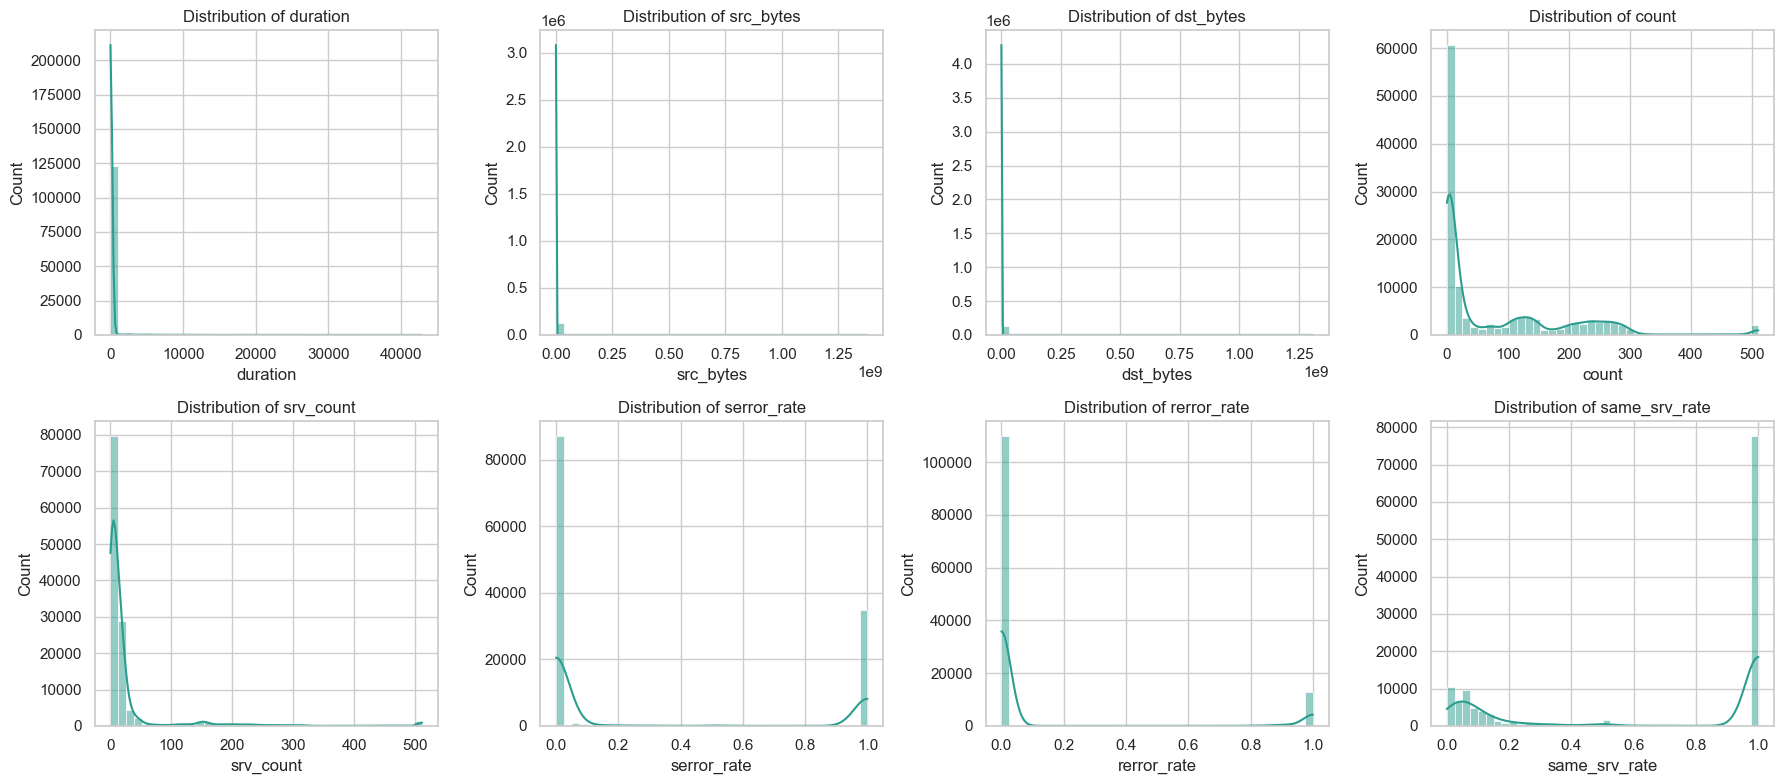

In [16]:

hist_features = [c for c in ["duration", "src_bytes", "dst_bytes", "count", "srv_count", "serror_rate", "rerror_rate", "same_srv_rate"] if c in df_train_clean.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(hist_features):
    sns.histplot(df_train_clean[col], bins=40, kde=True, ax=axes[i], color="#2a9d8f")
    axes[i].set_title(f"Distribution of {col}")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()



**Interpretacion:** varias variables presentan asimetria positiva y colas largas, comportamiento frecuente en trafico de red con eventos extremos.



## 9.3 Boxplots por clase de ataque


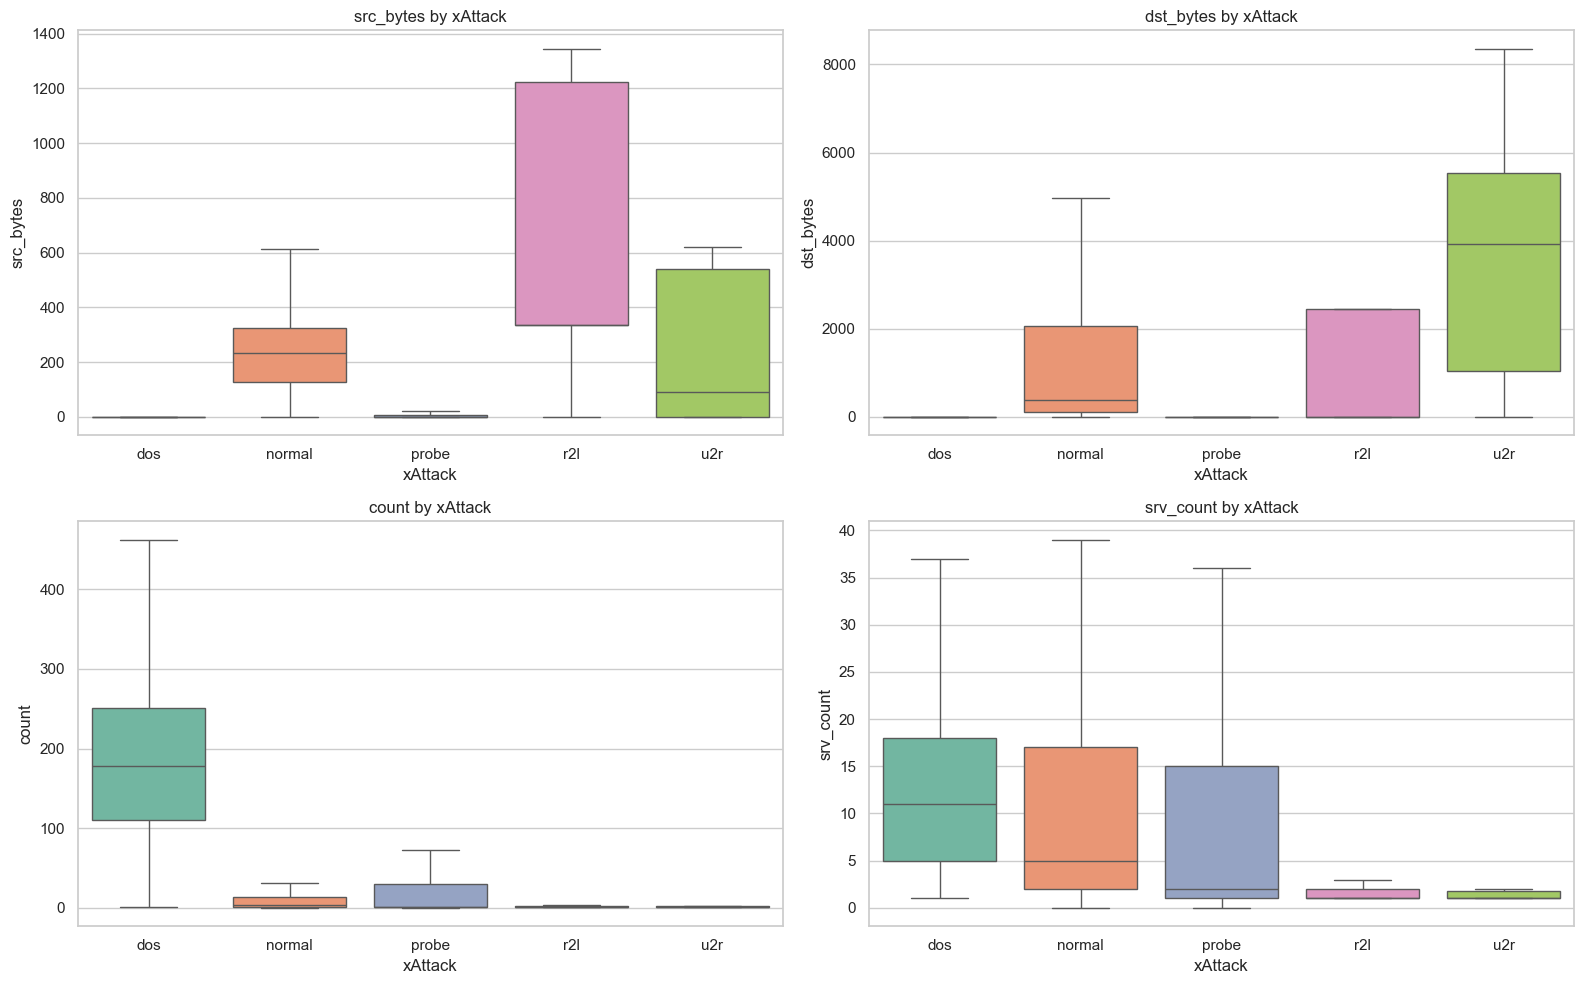

In [17]:

box_features = [c for c in ["src_bytes", "dst_bytes", "count", "srv_count"] if c in df_train_clean.columns]
sample_box = df_train_clean.sample(min(30000, len(df_train_clean)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(box_features):
    sns.boxplot(data=sample_box, x="xAttack", y=col, ax=axes[i], palette="Set2", showfliers=False)
    axes[i].set_title(f"{col} by xAttack")
    axes[i].set_xlabel("xAttack")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()



**Interpretacion:** se observan diferencias de dispersion y nivel central por clase, reforzando la capacidad discriminante de estas variables.



## 9.4 Protocolos y servicios codificados


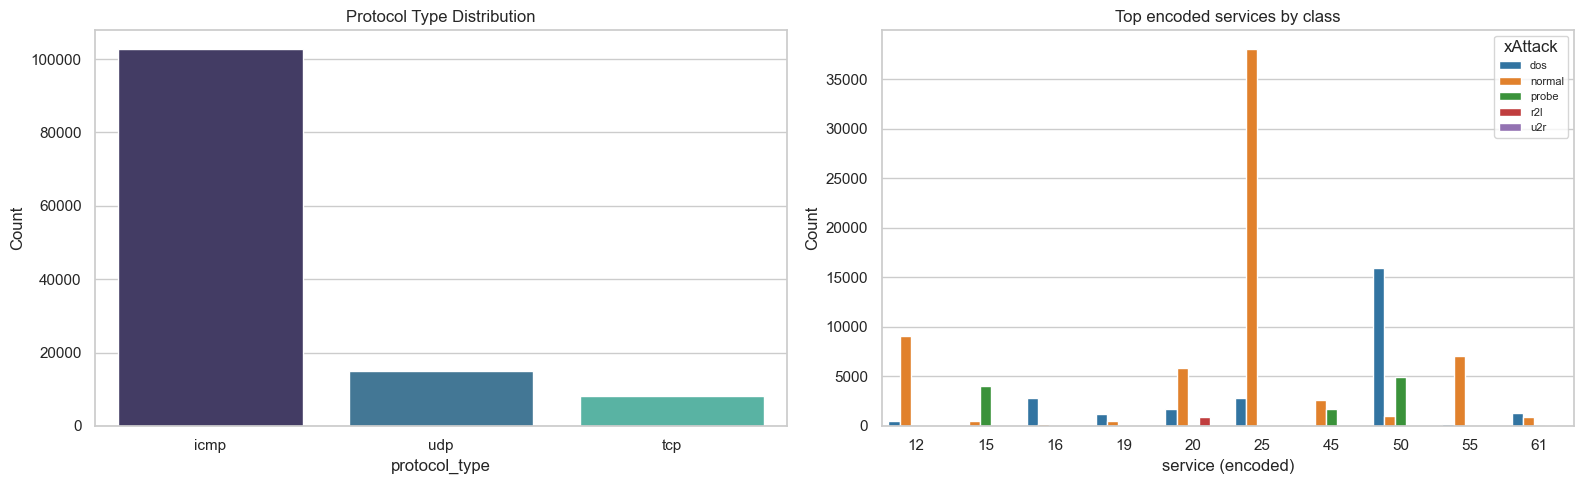

In [18]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(data=df_train_clean, x="protocol_type", order=df_train_clean["protocol_type"].value_counts().index, ax=axes[0], palette="mako")
axes[0].set_title("Protocol Type Distribution")
axes[0].set_xlabel("protocol_type")
axes[0].set_ylabel("Count")

if "service" in df_train_clean.columns:
    top_services = df_train_clean["service"].value_counts().head(10).index
    service_df = df_train_clean[df_train_clean["service"].isin(top_services)]
    sns.countplot(data=service_df, x="service", hue="xAttack", ax=axes[1], palette="tab10")
    axes[1].set_title("Top encoded services by class")
    axes[1].set_xlabel("service (encoded)")
    axes[1].set_ylabel("Count")
    axes[1].legend(title="xAttack", fontsize=8)

plt.tight_layout()
plt.show()



**Interpretacion:** el perfil por protocolo y servicio codificado cambia segun la clase, aportando senales utiles para deteccion supervisada.



## 9.5 Scatter de volumen de trafico


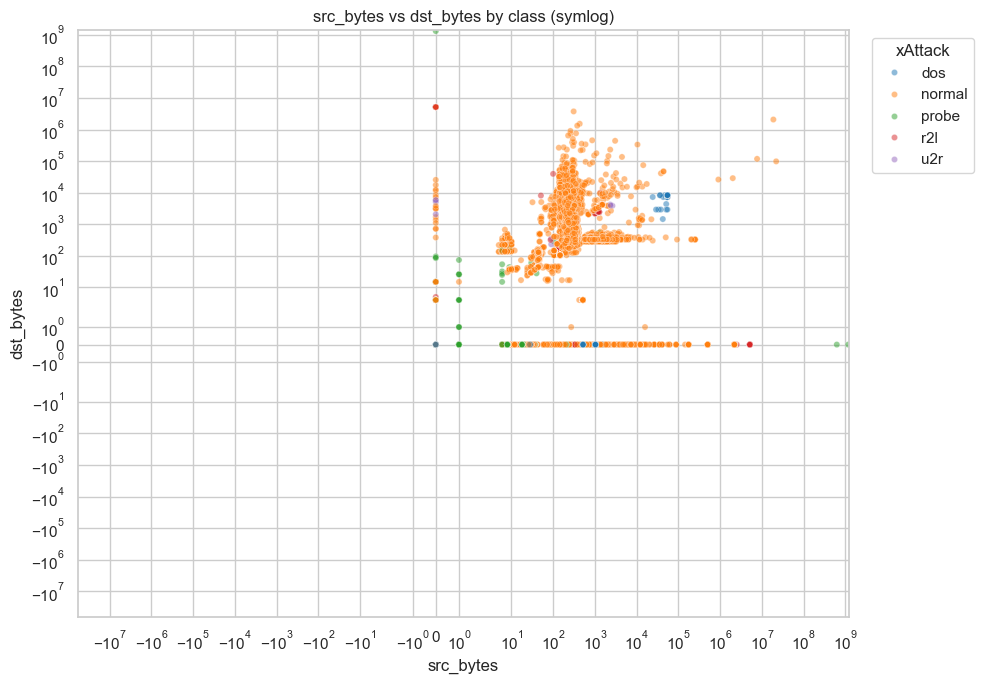

In [19]:

scatter_sample = df_train_clean.sample(min(25000, len(df_train_clean)), random_state=RANDOM_STATE)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=scatter_sample,
    x="src_bytes",
    y="dst_bytes",
    hue="xAttack",
    alpha=0.5,
    s=20,
    palette="tab10",
)
plt.xscale("symlog")
plt.yscale("symlog")
plt.title("src_bytes vs dst_bytes by class (symlog)")
plt.xlabel("src_bytes")
plt.ylabel("dst_bytes")
plt.legend(title="xAttack", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()



**Interpretacion:** aparecen regiones de densidad diferenciadas y eventos de alto volumen compatibles con comportamiento anomalo.



# 10. Correlation Analysis

Se calcula correlacion en variables numericas. Para interpretar asociacion con amenaza, se agrega variable binaria auxiliar `is_attack` (`1` si clase distinta de `normal`).


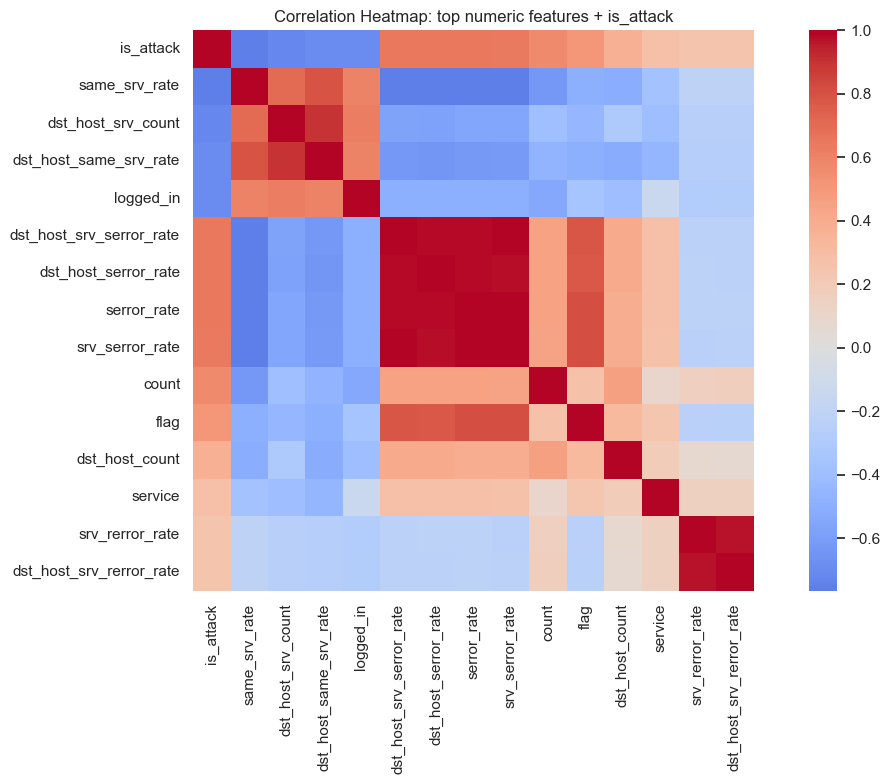

,corr_with_is_attack
is_attack,1.000000
dst_host_srv_serror_rate,0.655018
dst_host_serror_rate,0.651875
serror_rate,0.650685
srv_serror_rate,0.648320
count,0.576509
flag,0.508670
dst_host_count,0.375165
service,0.279234
srv_rerror_rate,0.253590


In [20]:

df_corr = df_train_clean.copy()
df_corr["is_attack"] = (df_corr["xAttack"].astype(str) != "normal").astype(int)

numeric_cols = df_corr.select_dtypes(include=np.number).columns.tolist()

corr_target_abs = df_corr[numeric_cols].corr()["is_attack"].abs().sort_values(ascending=False)
top_corr_cols = corr_target_abs.head(15).index.tolist()

corr_matrix = df_corr[top_corr_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False, square=True)
plt.title("Correlation Heatmap: top numeric features + is_attack")
plt.tight_layout()
plt.show()

corr_with_attack = (
    df_corr[top_corr_cols]
    .corr()["is_attack"]
    .sort_values(ascending=False)
    .to_frame("corr_with_is_attack")
)

display(corr_with_attack)



**Interpretacion:** el heatmap evidencia grupos de variables relacionadas y features con mayor asociacion al comportamiento malicioso, insumo util para priorizar indicadores de monitoreo.



# 11. Cybersecurity Insights

Se sintetizan hallazgos con enfoque operativo para diferenciar trafico normal y trafico malicioso.


In [21]:

df_ins = df_train_clean.copy()
df_ins["is_attack"] = (df_ins["xAttack"].astype(str) != "normal").astype(int)

num_cols_ins = [c for c in df_ins.select_dtypes(include=np.number).columns if c != "is_attack"]

stats = df_ins.groupby("is_attack", observed=False)[num_cols_ins].agg(["mean", "std"])
mean_attack = stats.loc[1].xs("mean", level=1)
mean_normal = stats.loc[0].xs("mean", level=1)
std_global = df_ins[num_cols_ins].std().replace(0, np.nan)

smd = ((mean_attack - mean_normal) / std_global).replace([np.inf, -np.inf], np.nan).dropna()
insight_table = smd.abs().sort_values(ascending=False).head(12).to_frame("abs_standardized_mean_diff")
insight_table["direction_attack_minus_normal"] = smd.loc[insight_table.index].round(4)

display(insight_table)

protocol_attack_ratio = (
    df_ins.groupby("protocol_type", observed=False)["is_attack"]
    .mean()
    .sort_values(ascending=False)
    .to_frame("attack_ratio")
)

display(protocol_attack_ratio)


,abs_standardized_mean_diff,direction_attack_minus_normal
same_srv_rate,1.507673,-1.5077
dst_host_srv_count,1.448415,-1.4484
dst_host_same_srv_rate,1.391105,-1.3911
logged_in,1.383551,-1.3836
dst_host_srv_serror_rate,1.313200,1.3132
dst_host_serror_rate,1.306899,1.3069
serror_rate,1.304513,1.3045
srv_serror_rate,1.299772,1.2998
count,1.155802,1.1558
flag,1.019797,1.0198


,attack_ratio
protocol_type,
tcp,0.841946
icmp,0.477919
udp,0.170680



**Cybersecurity insights clave**

- Variables de tasa y error, junto con variables de volumen/conteo, muestran alta separacion entre trafico normal y malicioso.
- La proporcion de ataque cambia por `protocol_type`, por lo que el contexto de protocolo aporta valor a la deteccion.
- El desbalance de clases implica que accuracy aislada no es suficiente para evaluar efectividad defensiva.



# 12. Machine Learning (Baseline)

Dado que el dataset incluye `xAttack`, se entrena un modelo base multiclase usando `RandomForestClassifier`.

Flujo:

1. separar `X` e `y`;
2. split estratificado train/validation;
3. one-hot encoding para categoricas;
4. entrenamiento;
5. evaluacion con accuracy, precision, recall, f1 y confusion matrix.


In [22]:

target_col = "xAttack"

X = df_train_clean.drop(columns=[target_col])
y = df_train_clean[target_col].astype(str)

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols_model = [c for c in X.columns if c not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols_model),
    ]
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    class_weight="balanced_subsample",
    n_jobs=1,
)

clf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ]
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_valid)

metrics_table = pd.DataFrame(
    {
        "metric": ["accuracy", "precision_macro", "recall_macro", "f1_macro", "f1_weighted"],
        "value": [
            accuracy_score(y_valid, y_pred),
            precision_score(y_valid, y_pred, average="macro", zero_division=0),
            recall_score(y_valid, y_pred, average="macro", zero_division=0),
            f1_score(y_valid, y_pred, average="macro", zero_division=0),
            f1_score(y_valid, y_pred, average="weighted", zero_division=0),
        ],
    }
)
metrics_table["value"] = metrics_table["value"].round(4)

display(metrics_table)


,metric,value
0,accuracy,0.9990
1,precision_macro,0.9710
2,recall_macro,0.8857
3,f1_macro,0.9165
4,f1_weighted,0.9990


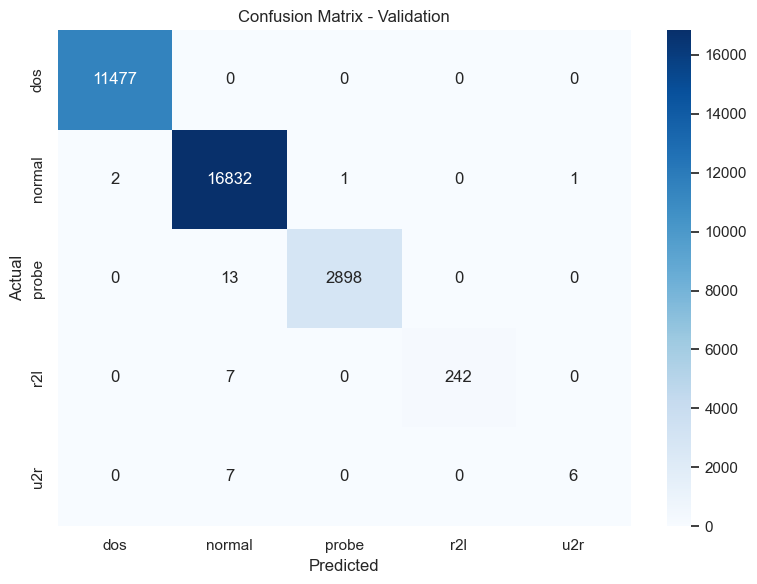

Classification report (validation):
              precision    recall  f1-score   support

         dos       1.00      1.00      1.00     11477
      normal       1.00      1.00      1.00     16836
       probe       1.00      1.00      1.00      2911
         r2l       1.00      0.97      0.99       249
         u2r       0.86      0.46      0.60        13

    accuracy                           1.00     31486
   macro avg       0.97      0.89      0.92     31486
weighted avg       1.00      1.00      1.00     31486



In [23]:

labels = sorted(y.unique())
cm = confusion_matrix(y_valid, y_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix - Validation")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print("Classification report (validation):")
print(classification_report(y_valid, y_pred, zero_division=0))


In [24]:

if target_col in df_test_clean.columns:
    X_test_ext = df_test_clean.drop(columns=[target_col])
    y_test_ext = df_test_clean[target_col].astype(str)

    y_test_pred = clf.predict(X_test_ext)

    ext_metrics = pd.DataFrame(
        {
            "metric": ["accuracy", "precision_macro", "recall_macro", "f1_macro", "f1_weighted"],
            "value": [
                accuracy_score(y_test_ext, y_test_pred),
                precision_score(y_test_ext, y_test_pred, average="macro", zero_division=0),
                recall_score(y_test_ext, y_test_pred, average="macro", zero_division=0),
                f1_score(y_test_ext, y_test_pred, average="macro", zero_division=0),
                f1_score(y_test_ext, y_test_pred, average="weighted", zero_division=0),
            ],
        }
    )
    ext_metrics["value"] = ext_metrics["value"].round(4)

    print("External test-set metrics:")
    display(ext_metrics)
else:
    print("No target column in test set. External evaluation skipped.")


External test-set metrics:


,metric,value
0,accuracy,0.7378
1,precision_macro,0.8866
2,recall_macro,0.4701
3,f1_macro,0.4723
4,f1_weighted,0.6905



**Interpretacion del baseline**

El modelo ofrece una referencia inicial util. Dado el desbalance, la lectura principal debe centrarse en metricas macro y en errores entre clases minoritarias.



# 13. Conclusions

## Hallazgos principales

- Se identificaron patrones diferenciales entre trafico normal y malicioso en tasas de error, volumen y conteos.
- La variable `protocol_type` aporta contexto relevante para caracterizar riesgo.
- El problema presenta clases raras (`u2r`, `r2l`) con alto valor operativo.

## Limitaciones

- Existen variables codificadas numericamente (por ejemplo `service`, `flag`) sin diccionario semantico extendido en este repositorio.
- El desbalance puede degradar recall de clases minoritarias.
- Esta fase no incluye optimizacion exhaustiva de hiperparametros.

## Trabajo futuro

1. Aplicar validacion cruzada estratificada y ajuste de hiperparametros.
2. Comparar algoritmos adicionales (por ejemplo Logistic Regression y Gradient Boosting).
3. Incorporar interpretabilidad (feature importance y SHAP) para apoyo a SOC.
4. Evaluar enfoque binario temprano (`normal` vs `attack`) como capa inicial de alerta.
